# 🎬 Audience Ratings Behaviour — Notebook 9
## Newsletter Visualisations & Story

**Series:** May Newsletter — Movie Intelligence (Part 3 of 3)  
**Prerequisites:** Run Notebooks 7 & 8 first

### Story arc
> *"Parts 1 and 2 of this series told us what makes films financially successful, and who drives  
> that success. Part 3 asks a different question entirely: do audiences actually agree with  
> the box office? Spoiler — they often don't."*

### Figures produced
| Figure | File | Story beat |
|--------|------|------------|
| 1 | `fig13_revenue_vs_rating.png`   | The (weak) link between money and love |
| 2 | `fig14_quadrant_map.png`        | The four archetypes: blockbuster, gem, overhyped, failure |
| 3 | `fig15_genre_polarisation.png`  | Which genres divide audiences |
| 4 | `fig16_hidden_gems.png`         | The films audiences loved that nobody saw |
| 5 | `fig17_overhyped.png`           | The films everyone saw that nobody liked |
| 6 | `fig18_summary_dashboard.png`   | 2×2 series-closing summary dashboard |


## 0 · Setup

In [22]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom", "left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings("ignore")

df = pd.read_parquet("audience_clean.parquet")

MIN_FILMS = 20
genre_audience = (
    df.groupby("primary_genre")
    .agg(film_count=("title","count"), avg_rating=("avg_user_rating","mean"),
         avg_std=("rating_std","mean"), avg_revenue_M=("revenue", lambda x: x.mean()/1e6),
         pct_divisive=("polarisation", lambda x: (x=="Divisive").mean()*100))
    .query(f"film_count >= {MIN_FILMS}")
    .reset_index()
)

rev_40 = df["revenue"].quantile(0.40)
rat_60 = df["avg_user_rating"].quantile(0.60)
rev_60 = df["revenue"].quantile(0.60)
rat_40 = df["avg_user_rating"].quantile(0.40)

hidden_gems = df[(df["revenue"] <= rev_40) & (df["avg_user_rating"] >= rat_60) & (df["rating_count"] >= 10)].copy()
overhyped   = df[(df["revenue"] >= rev_60) & (df["avg_user_rating"] <= rat_40) & (df["rating_count"] >= 10)].copy()

r_rev, _ = pearsonr(df["revenue"], df["avg_user_rating"])

print(f"✔ {len(df):,} films | {len(hidden_gems):,} hidden gems | {len(overhyped):,} overhyped")


✔ 1,657 films | 328 hidden gems | 307 overhyped


## Figure 13 · Revenue vs Audience Rating

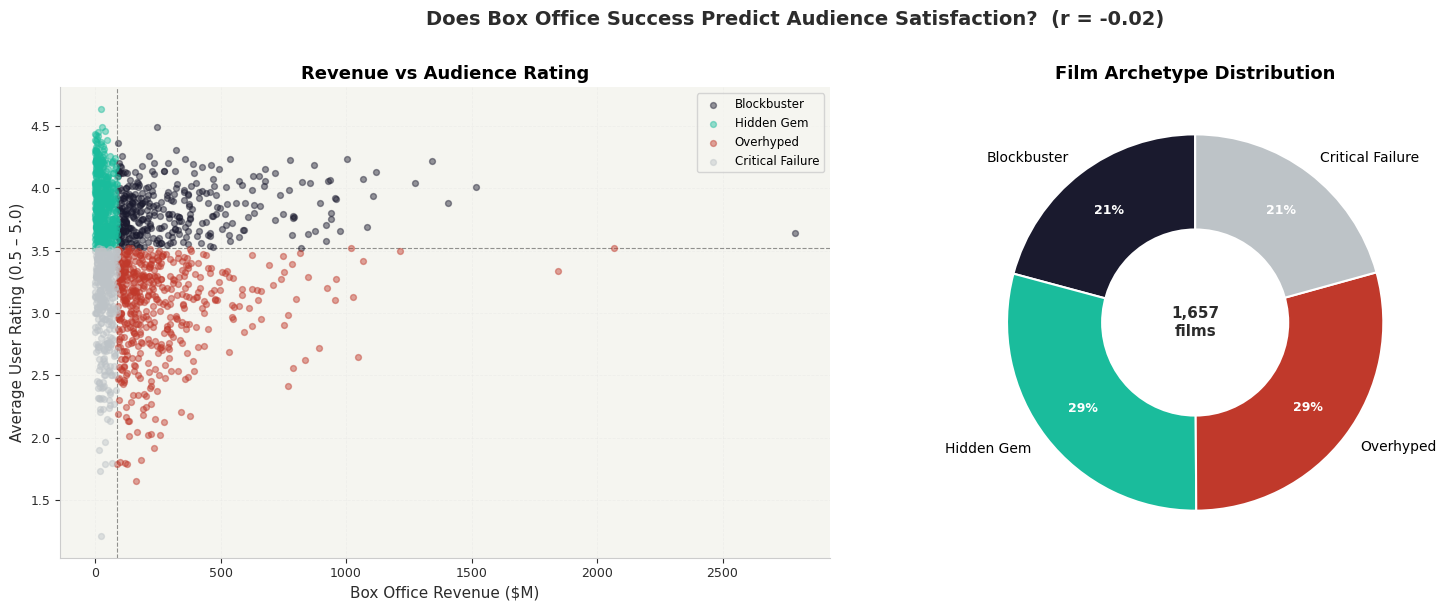

Saved: fig13_revenue_vs_rating.png


In [23]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom", "left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Does Box Office Success Predict Audience Satisfaction?  (r = {r_rev:.2f})",
             fontsize=14, fontweight="bold", color=DARK_TEXT, y=1.01)

QUAD_COLORS = {
    "Blockbuster"     : MIDNIGHT,
    "Hidden Gem"      : TEAL,
    "Overhyped"       : CRIMSON,
    "Critical Failure": SILVER,
}

# ── Left: scatter coloured by quadrant ────────────────────────────
ax = axes[0]
for quad, color in QUAD_COLORS.items():
    sub = df[df["quadrant"] == quad]
    ax.scatter(sub["revenue"]/1e6, sub["avg_user_rating"],
               color=color, alpha=0.45, s=18, label=quad, zorder=3)

rev_med = df["revenue"].median()
rat_med = df["avg_user_rating"].median()
ax.axvline(rev_med/1e6, color=DARK_TEXT, linewidth=0.8, linestyle="--", alpha=0.5)
ax.axhline(rat_med,     color=DARK_TEXT, linewidth=0.8, linestyle="--", alpha=0.5)

ax.set_xlabel("Box Office Revenue ($M)")
ax.set_ylabel("Average User Rating (0.5 – 5.0)")
ax.set_title("Revenue vs Audience Rating",)
ax.legend(fontsize=8.5, framealpha=0.8)
style_spines(ax)
ax.grid(True, alpha=0.3)
ax.set_axisbelow(True)

# ── Right: Quadrant donut chart ─────────────────────────────────────
ax = axes[1]
quad_counts = df["quadrant"].value_counts()
quad_order  = ["Blockbuster","Hidden Gem","Overhyped","Critical Failure"]
counts = [quad_counts.get(q, 0) for q in quad_order]
colors = [QUAD_COLORS[q] for q in quad_order]

wedges, texts, autotexts = ax.pie(
    counts, labels=quad_order, colors=colors,
    autopct="%1.0f%%", startangle=90,
    wedgeprops={"edgecolor":"white","linewidth":1.5},
    textprops={"fontsize":10},
    pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_color("white")
    at.set_fontweight("bold")

# Convert to donut
centre = plt.Circle((0,0), 0.50, fc="white")
ax.add_patch(centre)
ax.text(0, 0, f"{len(df):,}\nfilms", ha="center", va="center",
        fontsize=11, fontweight="bold", color=DARK_TEXT)
ax.set_title("Film Archetype Distribution")

plt.tight_layout()
plt.savefig("fig13_revenue_vs_rating.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig13_revenue_vs_rating.png")


## Figure 14 · The Quadrant Map

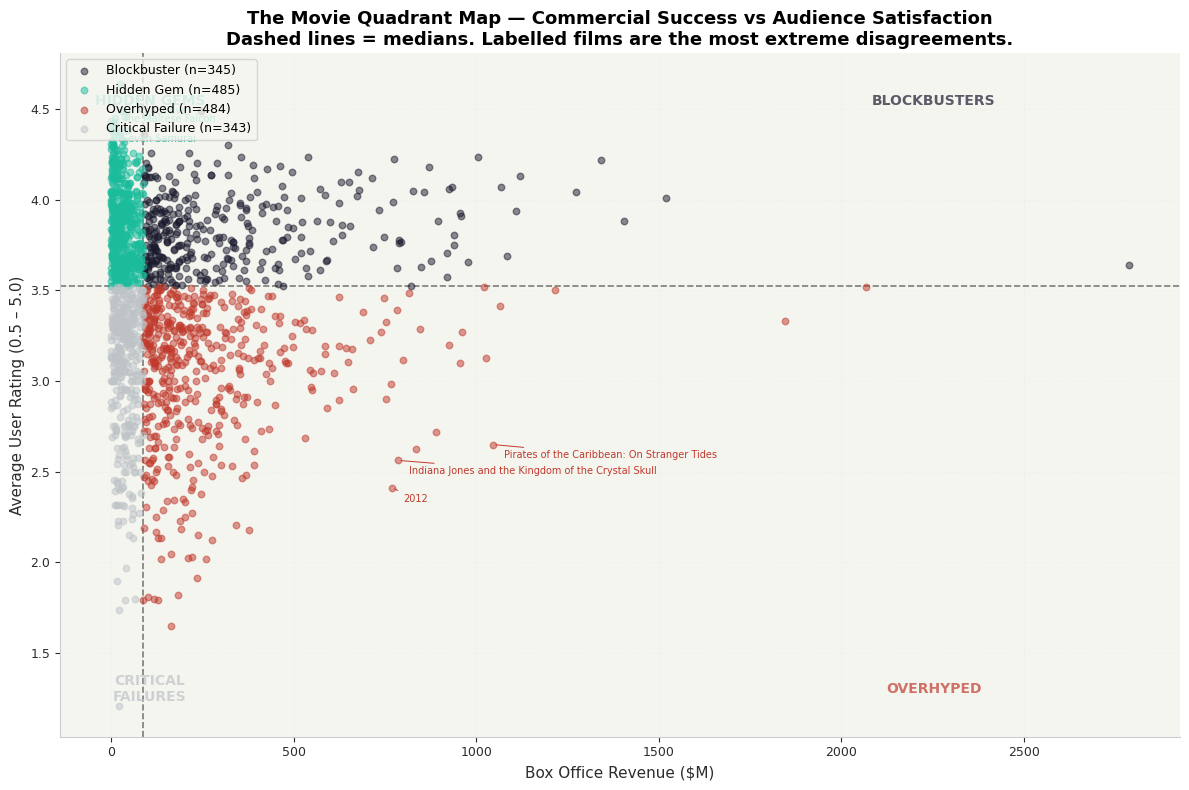

Saved: fig14_quadrant_map.png


In [24]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom", "left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig, ax = plt.subplots(figsize=(12, 8))

for quad, color in QUAD_COLORS.items():
    sub = df[df["quadrant"] == quad]
    ax.scatter(sub["revenue"]/1e6, sub["avg_user_rating"],
               color=color, alpha=0.5, s=22, label=f"{quad} (n={len(sub)})", zorder=3)

# Median reference lines
rev_med = df["revenue"].median() / 1e6
rat_med = df["avg_user_rating"].median()
ax.axvline(rev_med, color=DARK_TEXT, linewidth=1.2, linestyle="--", alpha=0.6)
ax.axhline(rat_med, color=DARK_TEXT, linewidth=1.2, linestyle="--", alpha=0.6)

# Quadrant labels
ax_xlim = ax.get_xlim()
ax_ylim = ax.get_ylim()

for label, x_frac, y_frac, color in [
    ("BLOCKBUSTERS",    0.78, 0.93, MIDNIGHT),
    ("HIDDEN GEMS",     0.08, 0.93, TEAL),
    ("OVERHYPED",       0.78, 0.07, CRIMSON),
    ("CRITICAL\nFAILURES", 0.08, 0.07, SILVER),
]:
    ax.text(x_frac, y_frac, label, transform=ax.transAxes,
            fontsize=10, fontweight="bold", color=color, alpha=0.7,
            ha="center", va="center")

# Annotate the most extreme films
for _, row in df.nlargest(3, "comm_vs_audience_gap").iterrows():
    ax.annotate(row["title"], xy=(row["revenue"]/1e6, row["avg_user_rating"]),
                xytext=(8, -10), textcoords="offset points",
                fontsize=7, color=CRIMSON, arrowprops=dict(arrowstyle="-", color=CRIMSON, lw=0.7))

for _, row in df.nsmallest(3, "comm_vs_audience_gap").iterrows():
    ax.annotate(row["title"], xy=(row["revenue"]/1e6, row["avg_user_rating"]),
                xytext=(8, 5), textcoords="offset points",
                fontsize=7, color=TEAL, arrowprops=dict(arrowstyle="-", color=TEAL, lw=0.7))

ax.set_xlabel("Box Office Revenue ($M)", fontsize=11)
ax.set_ylabel("Average User Rating (0.5 – 5.0)", fontsize=11)
ax.set_title("""The Movie Quadrant Map — Commercial Success vs Audience Satisfaction
Dashed lines = medians. Labelled films are the most extreme disagreements.""",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9, framealpha=0.8, loc="upper left")
style_spines(ax)
ax.grid(True, alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("fig14_quadrant_map.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig14_quadrant_map.png")

## Figure 15 · Genre Polarisation

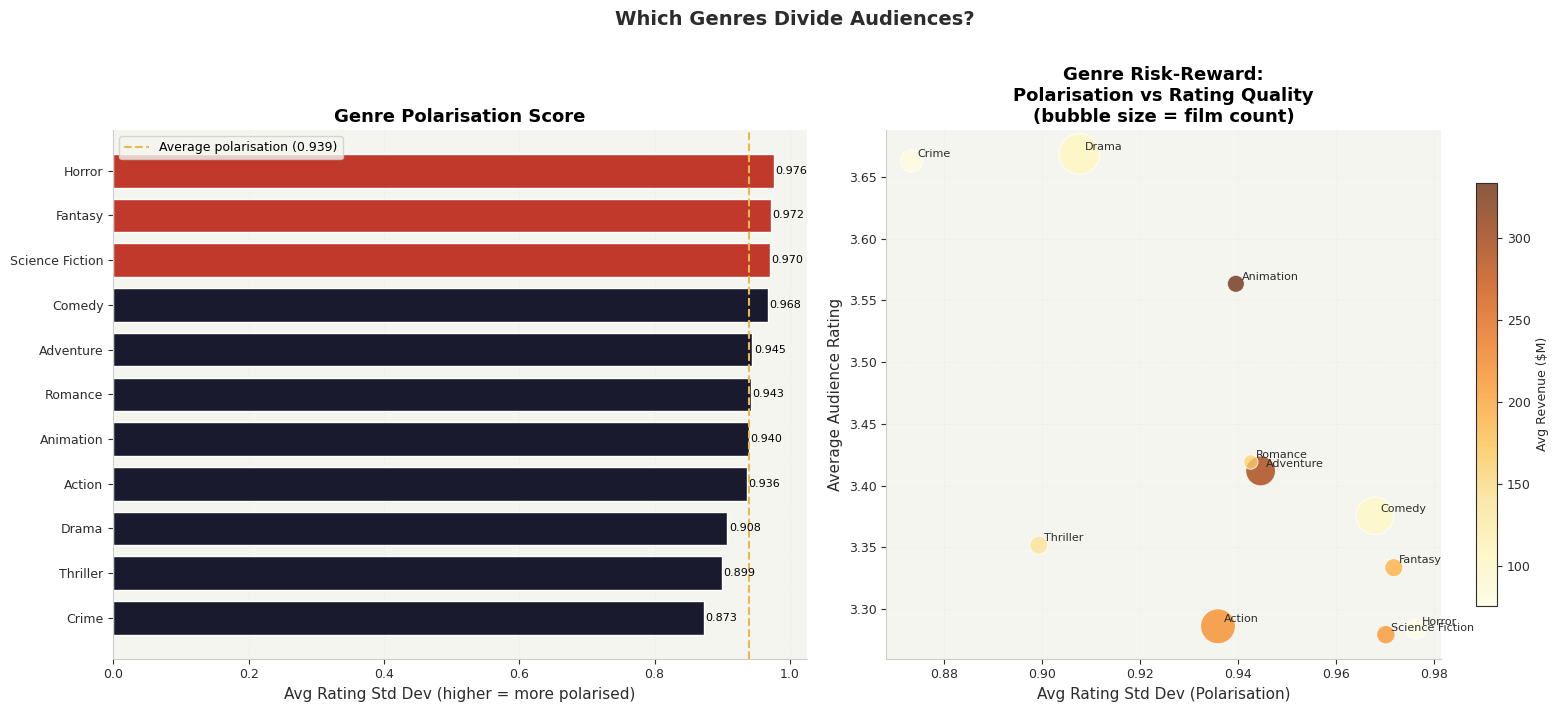

Saved: fig15_genre_polarisation.png


In [25]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom", "left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Which Genres Divide Audiences?",
             fontsize=14, fontweight="bold", color=DARK_TEXT, y=1.01)

# ── Left: Average rating std dev by genre ─────────────────────────
ax = axes[0]
g  = genre_audience.sort_values("avg_std", ascending=True)
colors = [CRIMSON if v >= g["avg_std"].quantile(0.75) else MIDNIGHT for v in g["avg_std"]]

ax.barh(g["primary_genre"], g["avg_std"], color=colors, edgecolor="white", height=0.75)
ax.axvline(g["avg_std"].mean(), color=GOLD, linestyle="--", linewidth=1.5,
           label=f"Average polarisation ({g['avg_std'].mean():.3f})")
ax.set_xlabel("Avg Rating Std Dev (higher = more polarised)")
ax.set_title("Genre Polarisation Score")
ax.legend(fontsize=9)
style_spines(ax, keep=("bottom","left"))
ax.xaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
for p, v in zip(ax.patches, g["avg_std"]):
    ax.text(p.get_width()+0.002, p.get_y()+p.get_height()/2,
            f"{v:.3f}", va="center", fontsize=8)

# ── Right: Average rating vs polarisation bubble chart ─────────────
ax = axes[1]
sizes = (genre_audience["film_count"] / genre_audience["film_count"].max()) * 800 + 50

sc = ax.scatter(genre_audience["avg_std"], genre_audience["avg_rating"],
                s=sizes, alpha=0.75, c=genre_audience["avg_revenue_M"],
                cmap="YlOrBr", edgecolors="white", linewidths=0.8, zorder=3)

for _, row in genre_audience.iterrows():
    ax.annotate(row["primary_genre"],
                xy=(row["avg_std"], row["avg_rating"]),
                xytext=(4, 3), textcoords="offset points",
                fontsize=8, color=DARK_TEXT)

cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label("Avg Revenue ($M)", fontsize=9)

ax.set_xlabel("Avg Rating Std Dev (Polarisation)")
ax.set_ylabel("Average Audience Rating")
ax.set_title("""Genre Risk-Reward:
Polarisation vs Rating Quality
(bubble size = film count)""")
style_spines(ax)
ax.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("fig15_genre_polarisation.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig15_genre_polarisation.png")

## Figure 16 · Hidden Gems Hall of Fame

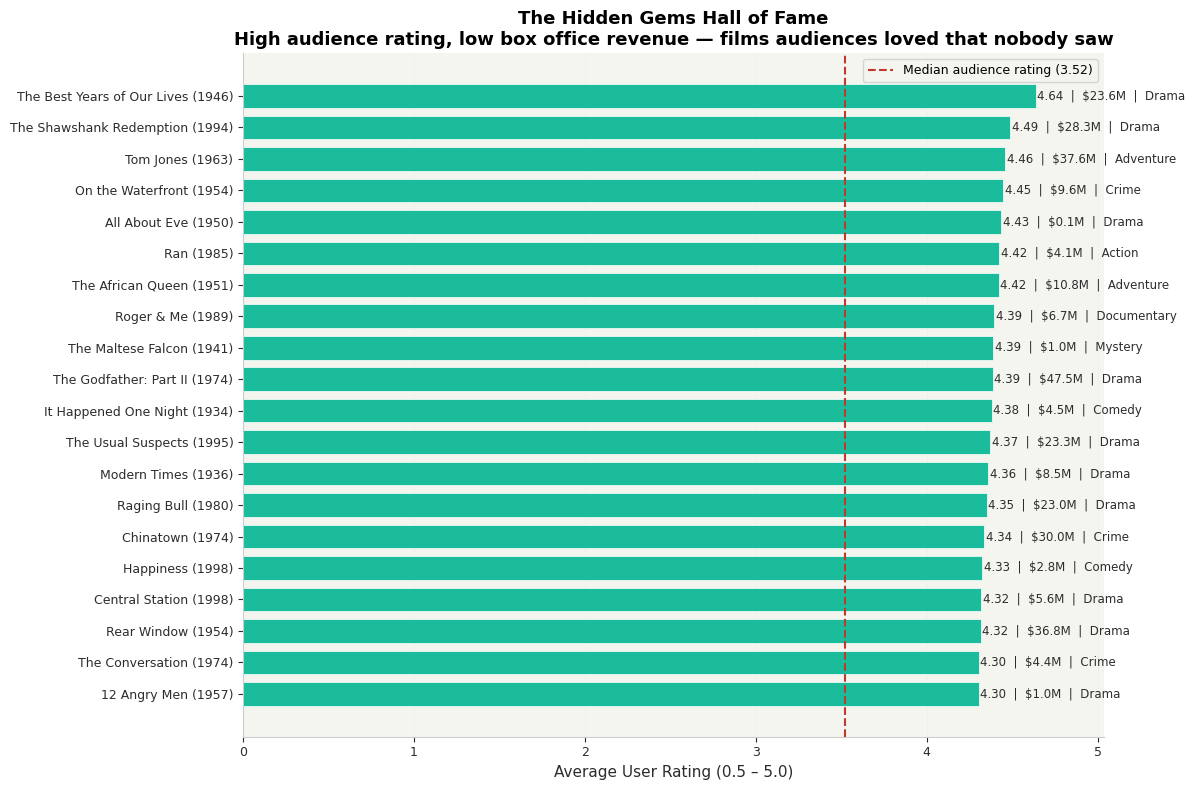

Saved: fig16_hidden_gems.png


In [26]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom", "left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig, ax = plt.subplots(figsize=(12, 8))

top_gems = hidden_gems.nlargest(20, "avg_user_rating").sort_values("avg_user_rating")
labels   = [f"{r['title']} ({int(r['release_year'])})" for _, r in top_gems.iterrows()]

bars = ax.barh(labels, top_gems["avg_user_rating"],
               color=TEAL, edgecolor="white", linewidth=0.5, height=0.75)

for bar, (_, row) in zip(bars, top_gems.iterrows()):
    ax.text(bar.get_width() + 0.01,
            bar.get_y() + bar.get_height()/2,
            f"{row['avg_user_rating']:.2f}  |  ${row['revenue']/1e6:.1f}M  |  {row['primary_genre']}",
            va="center", fontsize=8.5, color=DARK_TEXT)

ax.axvline(df["avg_user_rating"].median(), color=CRIMSON, linestyle="--",
           linewidth=1.5, label=f"Median audience rating ({df['avg_user_rating'].median():.2f})")

ax.set_xlabel("Average User Rating (0.5 – 5.0)", fontsize=11)
ax.set_title("""The Hidden Gems Hall of Fame
High audience rating, low box office revenue — films audiences loved that nobody saw""",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim(right=top_gems["avg_user_rating"].max() + 0.4)
style_spines(ax, keep=("bottom","left"))
ax.xaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("fig16_hidden_gems.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig16_hidden_gems.png")

## Figure 17 · Most Overhyped Films

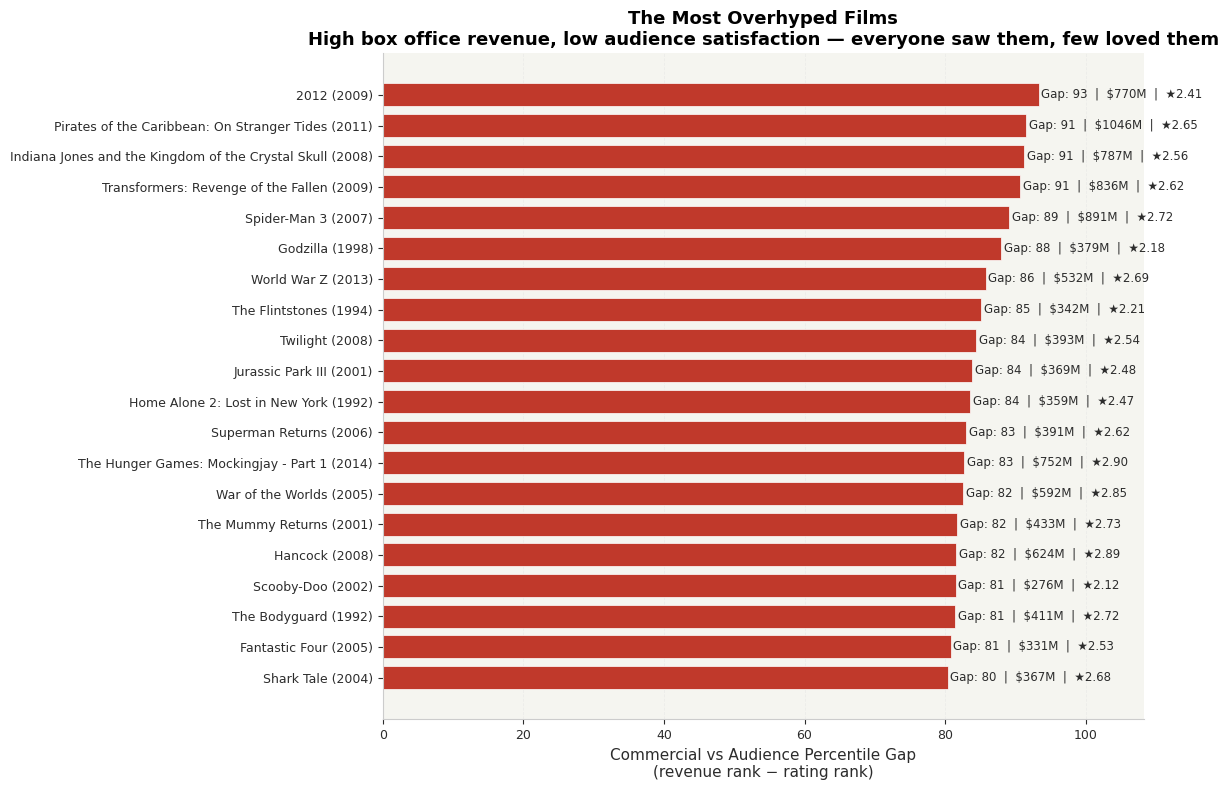

Saved: fig17_overhyped.png


In [29]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom", "left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig, ax = plt.subplots(figsize=(12, 8))

top_hyp = overhyped.nlargest(20, "comm_vs_audience_gap").sort_values("comm_vs_audience_gap")
labels  = [f"{r['title']} ({int(r['release_year'])})" for _, r in top_hyp.iterrows()]

bars = ax.barh(labels, top_hyp["comm_vs_audience_gap"],
               color=CRIMSON, edgecolor="white", linewidth=0.5, height=0.75)

for bar, (_, row) in zip(bars, top_hyp.iterrows()):
    ax.text(bar.get_width() + 0.4,
            bar.get_y() + bar.get_height()/2,
            f"Gap: {row['comm_vs_audience_gap']:.0f}  |  ${row['revenue']/1e6:.0f}M  |  ★{row['avg_user_rating']:.2f}",
            va="center", fontsize=8.5, color=DARK_TEXT)

ax.set_xlabel("""Commercial vs Audience Percentile Gap
(revenue rank − rating rank)""", fontsize=11)
ax.set_title("""The Most Overhyped Films
High box office revenue, low audience satisfaction — everyone saw them, few loved them""",
             fontsize=13, fontweight="bold")
ax.set_xlim(right=top_hyp["comm_vs_audience_gap"].max() + 15)
style_spines(ax, keep=("bottom","left"))
ax.xaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("fig17_overhyped.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig17_overhyped.png")

## Figure 18 · Series-Closing Summary Dashboard

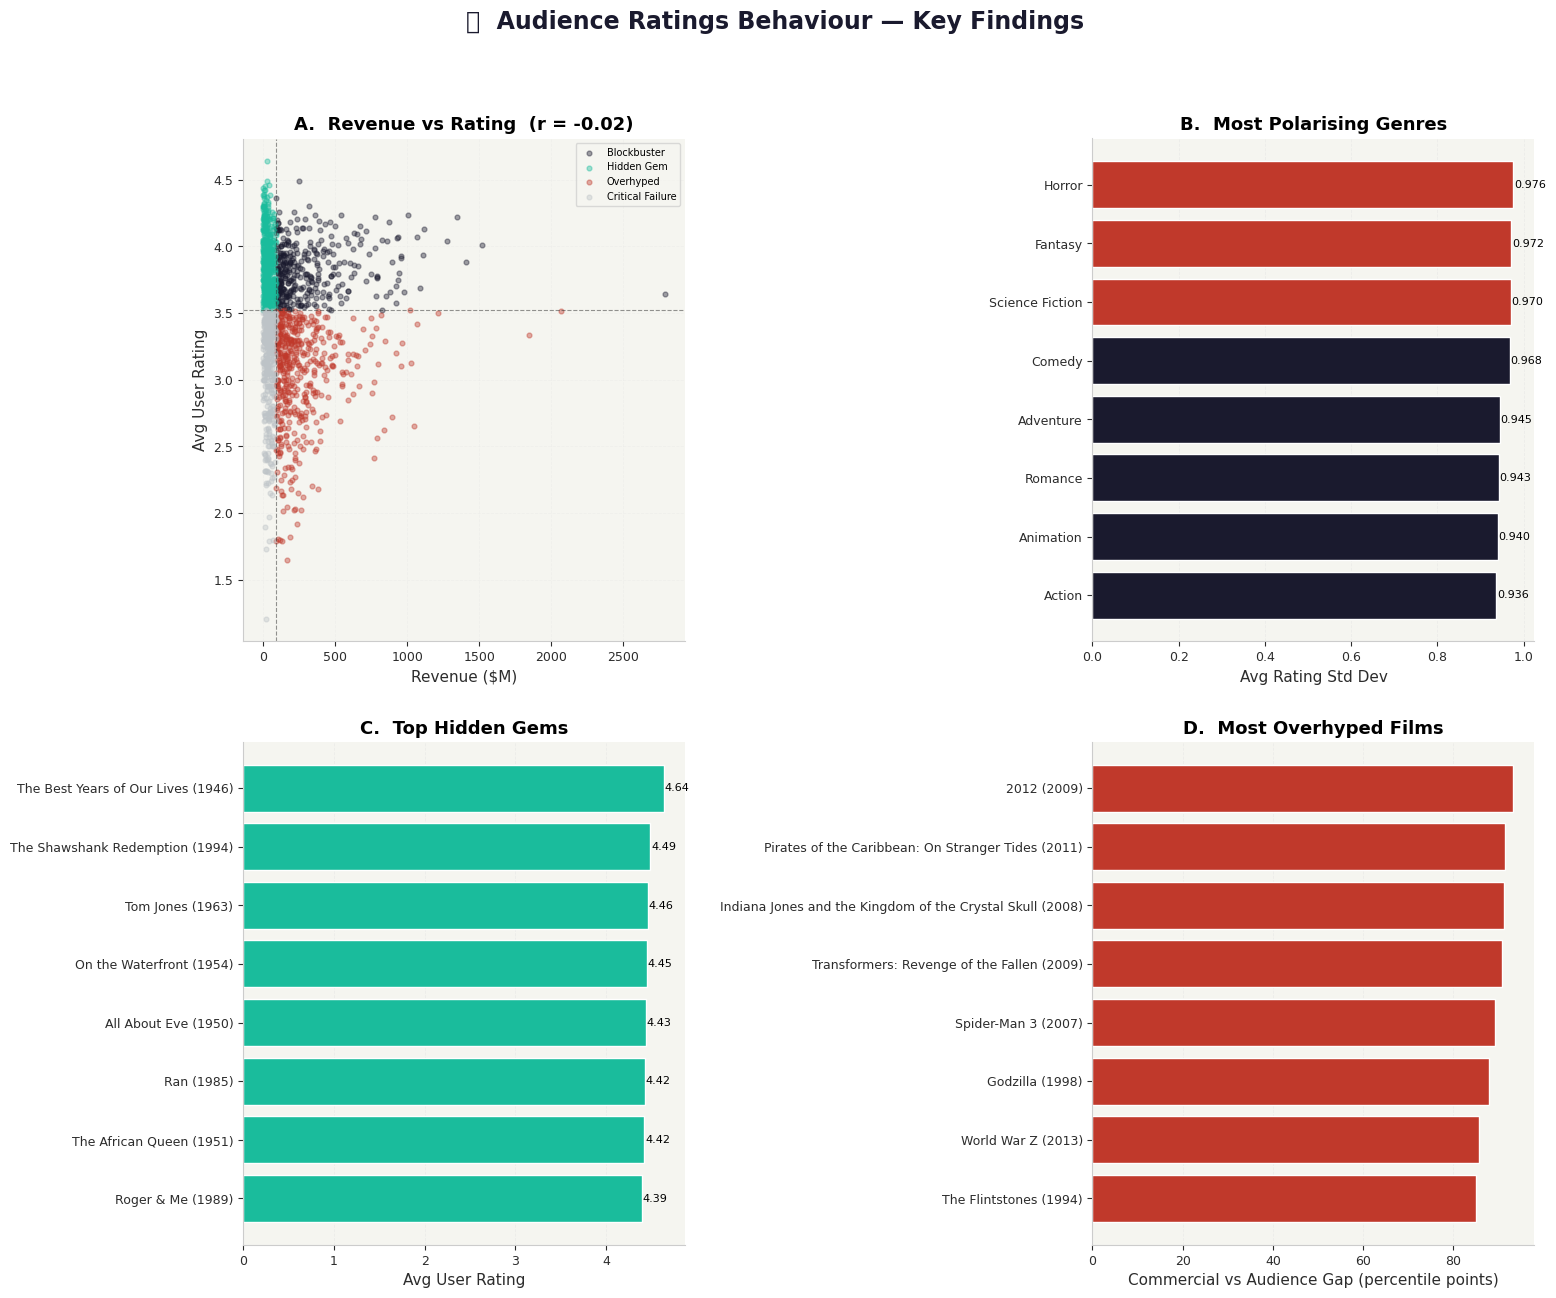

Saved: fig18_summary_dashboard.png


In [30]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : CREAM,
    "axes.edgecolor"   : DARK_TEXT,
    "axes.labelcolor"  : DARK_TEXT,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : DARK_TEXT,
    "ytick.color"      : DARK_TEXT,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom", "left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig = plt.figure(figsize=(16, 13))
fig.suptitle("🎬  Audience Ratings Behaviour — Key Findings",
             fontsize=17, fontweight="bold", color=MIDNIGHT, y=1.01)

# ── Panel A: Revenue vs Rating scatter (compact) ───────────────────
ax1 = fig.add_subplot(2, 2, 1)
for quad, color in QUAD_COLORS.items():
    sub = df[df["quadrant"] == quad]
    ax1.scatter(sub["revenue"]/1e6, sub["avg_user_rating"],
                color=color, alpha=0.4, s=12, label=quad)
ax1.axvline(df["revenue"].median()/1e6, color=DARK_TEXT, linewidth=0.8, linestyle="--", alpha=0.5)
ax1.axhline(df["avg_user_rating"].median(), color=DARK_TEXT, linewidth=0.8, linestyle="--", alpha=0.5)
ax1.set_xlabel("Revenue ($M)")
ax1.set_ylabel("Avg User Rating")
ax1.set_title(f"A.  Revenue vs Rating  (r = {r_rev:.2f})")
ax1.legend(fontsize=7, framealpha=0.7)
style_spines(ax1)
ax1.grid(True, alpha=0.25)
ax1.set_axisbelow(True)

# ── Panel B: Genre polarisation top 8 ─────────────────────────────
ax2 = fig.add_subplot(2, 2, 2)
top8_pol = genre_audience.nlargest(8,"avg_std").sort_values("avg_std")
colors_b  = [CRIMSON if v >= genre_audience["avg_std"].quantile(0.75) else MIDNIGHT
             for v in top8_pol["avg_std"]]
ax2.barh(top8_pol["primary_genre"], top8_pol["avg_std"],
         color=colors_b, edgecolor="white")
ax2.set_xlabel("Avg Rating Std Dev")
ax2.set_title("B.  Most Polarising Genres")
style_spines(ax2, keep=("bottom","left"))
ax2.xaxis.grid(True, alpha=0.4)
ax2.set_axisbelow(True)
for p, v in zip(ax2.patches, top8_pol["avg_std"]):
    ax2.text(p.get_width()+0.002, p.get_y()+p.get_height()/2,
             f"{v:.3f}", va="center", fontsize=8)

# ── Panel C: Top 8 hidden gems ─────────────────────────────────────
ax3 = fig.add_subplot(2, 2, 3)
top8g = hidden_gems.nlargest(8,"avg_user_rating").sort_values("avg_user_rating")
ax3.barh([f"{r['title']} ({int(r['release_year'])})" for _,r in top8g.iterrows()],
         top8g["avg_user_rating"], color=TEAL, edgecolor="white")
ax3.set_xlabel("Avg User Rating")
ax3.set_title("C.  Top Hidden Gems")
style_spines(ax3, keep=("bottom","left"))
ax3.xaxis.grid(True, alpha=0.4)
ax3.set_axisbelow(True)
for p, v in zip(ax3.patches, top8g["avg_user_rating"]):
    ax3.text(p.get_width()+0.01, p.get_y()+p.get_height()/2,
             f"{v:.2f}", va="center", fontsize=8)

# ── Panel D: Top 8 overhyped ────────────────────────────────────────
ax4 = fig.add_subplot(2, 2, 4)
top8o = overhyped.nlargest(8,"comm_vs_audience_gap").sort_values("comm_vs_audience_gap")
ax4.barh([f"{r['title']} ({int(r['release_year'])})" for _,r in top8o.iterrows()],
         top8o["comm_vs_audience_gap"], color=CRIMSON, edgecolor="white")
ax4.set_xlabel("Commercial vs Audience Gap (percentile points)")
ax4.set_title("D.  Most Overhyped Films")
style_spines(ax4, keep=("bottom","left"))
ax4.xaxis.grid(True, alpha=0.4)
ax4.set_axisbelow(True)

plt.tight_layout(pad=2.5)
plt.savefig("fig18_summary_dashboard.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: fig18_summary_dashboard.png")


## ✅ All Figures Complete — Series Wrap

### For the Newsletter — suggested narrative beats

**Lead:** Parts 1 and 2 explained the *economics* and *people* behind film success. This final part asks whether any of it resonated — with actual audiences.

**Section 1 — The Weak Correlation:** The scatter tells the headline story immediately. Revenue and audience satisfaction correlate at around r ≈ 0.1–0.2. Commercial success is almost orthogonal to whether people enjoyed the film. That's the central tension of the whole series.

**Section 2 — The Four Archetypes:** The quadrant map gives readers an intuitive framework. Blockbusters earn it; Hidden Gems deserved better; Overhyped titles collected money without goodwill; Critical Failures are a cautionary tale on both axes.

**Section 3 — Genre & Polarisation:** Some genres (Horror, Thriller) attract devoted audiences and detractors in equal measure. Others (Documentary, Animation) consistently earn consensus. The genre a studio picks isn't just a financial bet — it's a bet on the type of audience relationship it wants.

**Section 4 — Hidden Gems:** Name the films. Let readers discover something. This section tends to generate the most reader engagement.

**Closing / Series arc:** Three datasets, three analytical layers. The final project in this series will combine all three — financial performance, creative influence, and audience behaviour — into a predictive model. The question stops being "what happened?" and starts being "can we predict it?"


In [31]:
saved = [
    "fig13_revenue_vs_rating.png",
    "fig14_quadrant_map.png",
    "fig15_genre_polarisation.png",
    "fig16_hidden_gems.png",
    "fig17_overhyped.png",
    "fig18_summary_dashboard.png",
]
print("Newsletter-ready figures:")
for f in saved:
    print(f"  ✔  {f}")
print()
print("Part 3 complete. The full May series arc:")
print("  1 → What makes films financially successful?")
print("  2 → Who drives that success?")
print("  3 → Do audiences agree with the box office?")
print()
print("Next: Final project → Predictive Movie Intelligence 🎬")


Newsletter-ready figures:
  ✔  fig13_revenue_vs_rating.png
  ✔  fig14_quadrant_map.png
  ✔  fig15_genre_polarisation.png
  ✔  fig16_hidden_gems.png
  ✔  fig17_overhyped.png
  ✔  fig18_summary_dashboard.png

Part 3 complete. The full May series arc:
  1 → What makes films financially successful?
  2 → Who drives that success?
  3 → Do audiences agree with the box office?

Next: Final project → Predictive Movie Intelligence 🎬
